# HANDLE MISSING VALUES

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
df = pd.read_csv("loan_approval_data.csv")

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [38]:
categorical_cols = df.select_dtypes(include=["object"]).columns
numerical_cols = df.select_dtypes(include=["float64"]).columns

In [39]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])

In [40]:
cate_imp = SimpleImputer(strategy = "most_frequent")
df[categorical_cols] = cate_imp.fit_transform(df[categorical_cols])

# EDA (Exploratory Data Analysis)

Text(0.5, 1.0, 'Is Loan Approved or not ?')

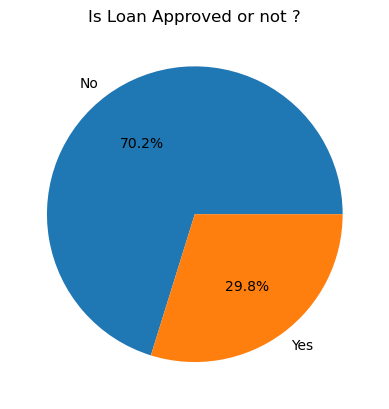

In [41]:
approval_cnt = df["Loan_Approved"].value_counts()
plt.pie(approval_cnt, labels=["No", "Yes"], autopct = "%1.1f%%")
plt.title("Is Loan Approved or not ?")

[Text(0, 0, '722'), Text(0, 0, '278')]

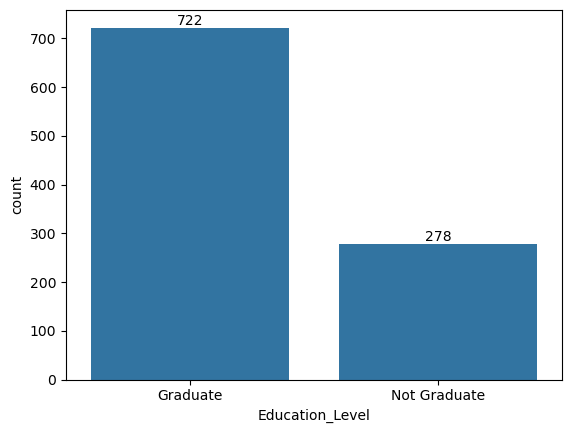

In [42]:
# gender_cnt = df["Gender"].value_counts()
# ax = sns.barplot(gender_cnt)
# ax.bar_label(ax.containers[0])

edu_cnt = df["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

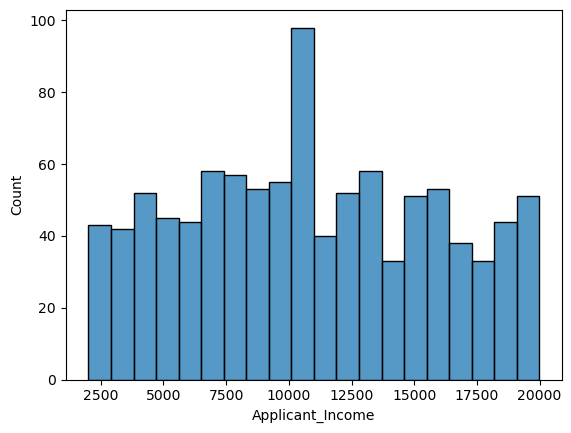

In [43]:
sns.histplot(
    data = df,
    bins = 20,
    x = "Applicant_Income"
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

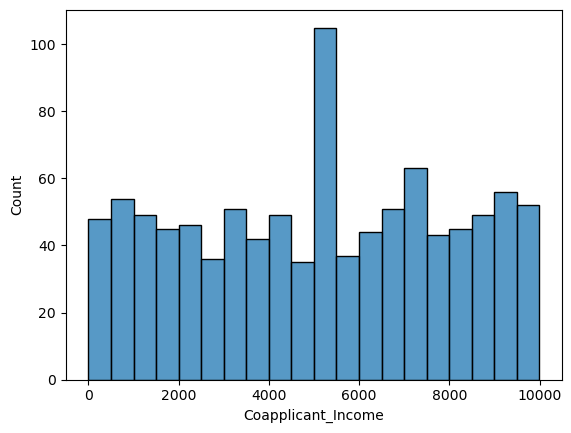

In [44]:
sns.histplot(
    data = df,
    bins = 20,
    x = "Coapplicant_Income"
)

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

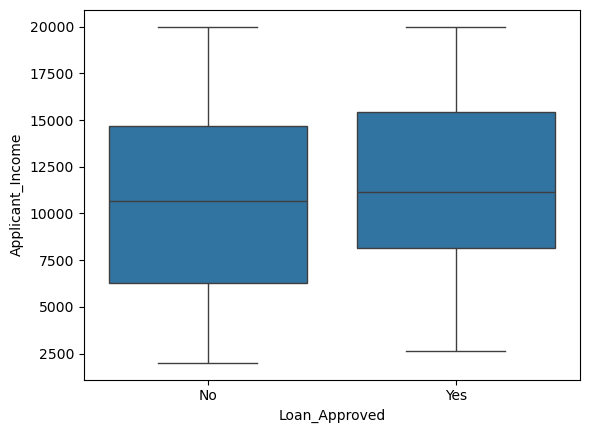

In [45]:
sns.boxplot(
    data = df,
    x = "Loan_Approved",
    y = "Applicant_Income"
)

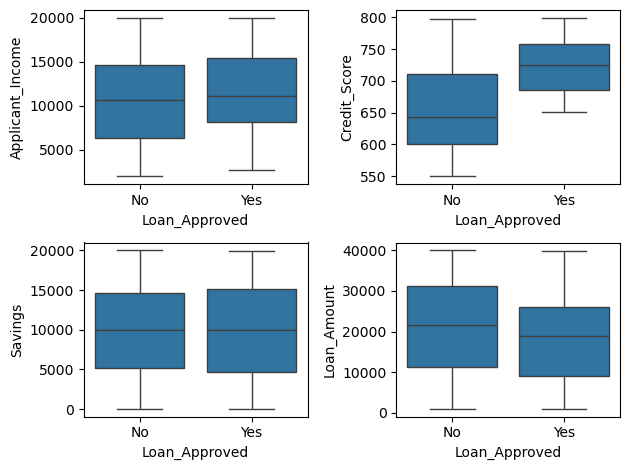

In [46]:
fig, axes = plt.subplots(2,2)
sns.boxplot(ax = axes[0,0],data = df,  x = "Loan_Approved", y = "Applicant_Income")
sns.boxplot(ax = axes[0,1],data = df,  x = "Loan_Approved", y = "Credit_Score")
sns.boxplot(ax = axes[1,0],data = df,  x = "Loan_Approved", y = "Savings")
sns.boxplot(ax = axes[1,1],data = df,  x = "Loan_Approved", y = "Loan_Amount")

plt.tight_layout()

<Axes: xlabel='Credit_Score', ylabel='Count'>

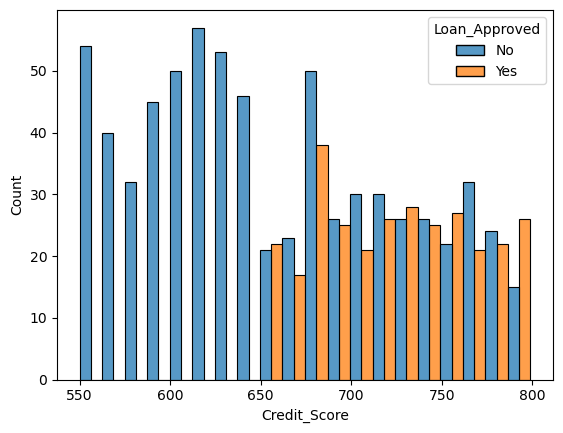

In [47]:
sns.histplot(
    data = df,
    x = "Credit_Score",
    bins = 20,
    hue = "Loan_Approved",
    multiple = "dodge"
)

In [48]:
df = df.drop(columns=["Applicant_ID"])

 # Encoding

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

In [50]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [51]:
from sklearn.preprocessing import OneHotEncoder

cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

ohe =  OneHotEncoder(drop = "first", sparse_output = False, handle_unknown="ignore")

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(encoded, columns = ohe.get_feature_names_out(cols), index = df.index)

df = pd.concat([df.drop(columns = cols),encoded_df], axis = 1)

# Co-relation Heatmap

<Axes: >

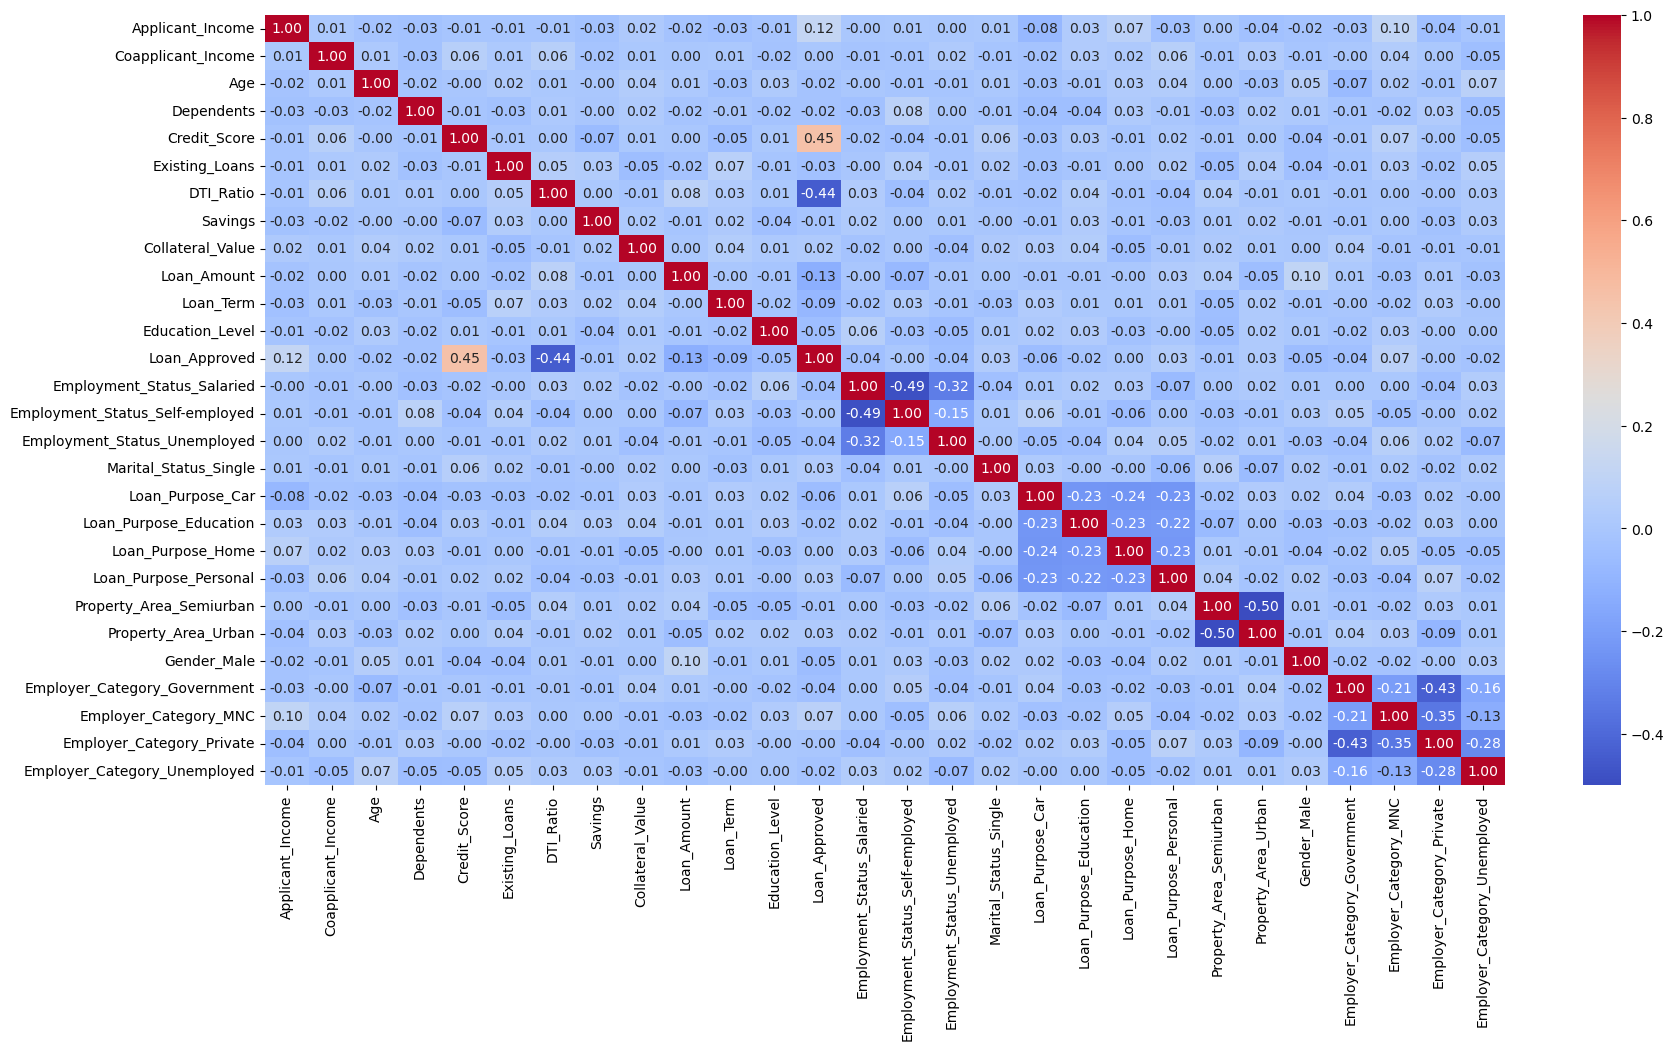

In [52]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

plt.figure(figsize=(20,10))
sns.heatmap(
    data = corr_matrix,
    fmt = ".2f",
    annot = True,
    cmap = "coolwarm"
)

In [53]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

# train_test_split & Feature Scaling


In [54]:
X = df.drop(columns=["Loan_Approved"])
y= df["Loan_Approved"]

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [56]:
from sklearn.preprocessing import StandardScaler

scaler =  StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train & Evaluate Model

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix, recall_score, f1_score

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)
print("Model - Logistic Regression")
print("precision_score:", precision_score(y_test, y_pred))
print("recall_score:", recall_score(y_test, y_pred))
print("f1_score:", f1_score(y_test, y_pred))
print("accuracy_score:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Model - Logistic Regression
precision_score: 0.7833333333333333
recall_score: 0.7704918032786885
f1_score: 0.7768595041322314
accuracy_score: 0.865
[[126  13]
 [ 14  47]]


In [58]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors = 11)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)
print("Model - kNN ")
print("precision_score:", precision_score(y_test, y_pred))
print("recall_score:", recall_score(y_test, y_pred))
print("f1_score:", f1_score(y_test, y_pred))
print("accuracy_score:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Model - kNN 
precision_score: 0.675
recall_score: 0.4426229508196721
f1_score: 0.5346534653465347
accuracy_score: 0.765
[[126  13]
 [ 34  27]]


In [59]:
from sklearn.naive_bayes import GaussianNB

NB_model = GaussianNB()
NB_model.fit(X_train_scaled, y_train)

y_pred = NB_model.predict(X_test_scaled)
print("Model - Naive Bayes")
print("precision_score:", precision_score(y_test, y_pred))
print("recall_score:", recall_score(y_test, y_pred))
print("f1_score:", f1_score(y_test, y_pred))
print("accuracy_score:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Model - Naive Bayes
precision_score: 0.8035714285714286
recall_score: 0.7377049180327869
f1_score: 0.7692307692307693
accuracy_score: 0.865
[[128  11]
 [ 16  45]]


#  Feature Engineering

In [63]:
import numpy as np
df["Credit_Score_sq"] = df["Credit_Score"] ** 2
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2

#df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

X = df.drop(columns=["Credit_Score","DTI_Ratio", "Loan_Approved"])
y = df["Loan_Approved"]

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

scaler =  StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [65]:
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)
print("Model - Logistic Regression")
print("precision_score:", precision_score(y_test, y_pred))
print("recall_score:", recall_score(y_test, y_pred))
print("f1_score:", f1_score(y_test, y_pred))
print("accuracy_score:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Model - Logistic Regression
precision_score: 0.7846153846153846
recall_score: 0.8360655737704918
f1_score: 0.8095238095238095
accuracy_score: 0.88
[[125  14]
 [ 10  51]]


In [66]:
knn_model = KNeighborsClassifier(n_neighbors = 11)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)
print("Model - kNN ")
print("precision_score:", precision_score(y_test, y_pred))
print("recall_score:", recall_score(y_test, y_pred))
print("f1_score:", f1_score(y_test, y_pred))
print("accuracy_score:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Model - kNN 
precision_score: 0.7317073170731707
recall_score: 0.4918032786885246
f1_score: 0.5882352941176471
accuracy_score: 0.79
[[128  11]
 [ 31  30]]


In [67]:
NB_model = GaussianNB()
NB_model.fit(X_train_scaled, y_train)

y_pred = NB_model.predict(X_test_scaled)
print("Model - Naive Bayes")
print("precision_score:", precision_score(y_test, y_pred))
print("recall_score:", recall_score(y_test, y_pred))
print("f1_score:", f1_score(y_test, y_pred))
print("accuracy_score:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Model - Naive Bayes
precision_score: 0.8113207547169812
recall_score: 0.7049180327868853
f1_score: 0.7543859649122807
accuracy_score: 0.86
[[129  10]
 [ 18  43]]
